24EE10029 Advitiya Apurv, 24EE10030 Afrin Munshi

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

CASE 1


In [ ]:

points = pd.read_csv("SVM_Case1_X.csv")
labels = pd.read_csv("SVM_Case1_Label.csv")

df = pd.concat([points, labels], axis=1)
print(df)

    -4.43295310931709  -1.03479207418407  -1
0            0.218857          -4.384093   1
1           -1.641510           2.801755  -1
2           -3.243310          -1.624161  -1
3           -2.910533           1.078659  -1
4            4.051536           2.412540   1
5            1.753912          -3.951868   1
6           -0.315318          -3.721116   1
7            4.121325           0.495401   1
8           -3.959884          -0.147706  -1
9            2.455461           3.904757  -1
10           2.362675           2.989603   1
11           0.618614           2.343411  -1
12          -3.158059          -4.486681   1
13           0.972114          -4.271147   1
14          -2.000630          -4.114725   1
15          -3.658771           2.983509  -1
16          -2.873985           4.430081  -1
17           3.949417           1.837156   1
18          -4.285472          -3.679170  -1
19          -2.575134           2.227245  -1
20          -4.462456          -3.896465  -1
21        

In [ ]:
data = df.to_numpy()
A = data[data[:, 2] == 1][:, :2]
B = data[data[:, 2] == -1][:, :2]

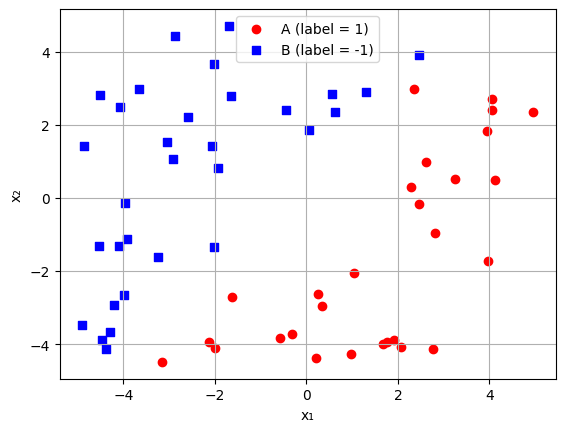

In [ ]:
plt.figure()


plt.scatter(A[:, 0], A[:, 1],color='red', marker='o', label='A (label = 1)')

plt.scatter(B[:, 0], B[:, 1], color='blue', marker='s', label='B (label = -1)')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X = np.vstack([A, B])
y = np.hstack([np.ones(A.shape[0]), -np.ones(B.shape[0])])
w = cp.Variable(2)
b = cp.Variable()
constraints = [
    cp.multiply(y, X @ w + b) >= 1
]
objective = cp.Minimize(cp.norm(w, 2))
problem= cp.Problem(objective, constraints)
result = problem.solve()


In [ ]:
w_opt = w.value
b_opt = b.value
x_min = X[:,0].min()
x_max = X[:,0].max()
xx = np.linspace(x_min, x_max, 400)

yy = -(w_opt[0] * xx + b_opt) / w_opt[1]

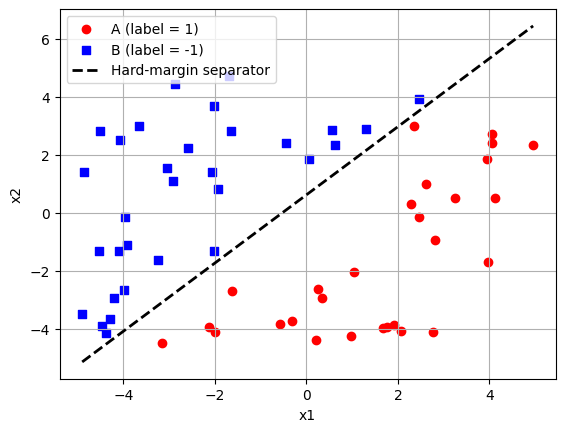

In [ ]:
plt.figure()

plt.scatter(A[:, 0], A[:, 1],color='red', marker='o', label='A (label = 1)')

plt.scatter(B[:, 0], B[:, 1], color='blue', marker='s', label='B (label = -1)')


plt.plot(xx, yy, 'k--', linewidth=2, label='Hard-margin separator')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()


Dual

In [ ]:
n_samples = X.shape[0]

Y = np.diag(y)
P = Y @ (X @ X.T) @ Y

lambd = cp.Variable(n_samples)


objective = cp.Maximize(cp.sum(lambd) - 0.5 * cp.quad_form(lambd, cp.psd_wrap(P)))

constraints = [
    lambd >= 0,
    cp.sum(cp.multiply(lambd, y)) == 0
]


prob = cp.Problem(objective, constraints)

In [ ]:

try:
    prob.solve(solver=cp.ECOS)
except cp.error.SolverError:
    prob.solve(solver=cp.SCS, verbose=True)

(CVXPY) Jan 29 11:25:14 AM: Your problem has 59 variables, 60 constraints, and 0 parameters.
(CVXPY) Jan 29 11:25:14 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 29 11:25:14 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jan 29 11:25:14 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 29 11:25:14 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jan 29 11:25:14 AM: Compiling problem (target solver=SCS).
(CVXPY) Jan 29 11:25:14 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Jan 29 11:25:14 AM: Applying reduction FlipObjective
(CVXPY) Jan 29 11:25:14 AM: Applying reduction Dcp2Cone
(CVXPY) Jan 29 11:25:14 AM: Applying reduction CvxAttr2Constr
(CVXPY) Jan 29 11:25:14 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Jan 29 11:25:14 AM: Applying redu

                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 59, constraints m: 60
cones: 	  z: primal zero / dual free vars: 1
	  l: linear vars: 59
settings: eps_abs:

In [ ]:
lambda_opt = lambd.value

w_dual = np.sum((lambda_opt[:, None] * y[:, None] * X), axis=0)


is_sv = lambda_opt > 1e-5
sv_indices = np.where(is_sv)[0]

if len(sv_indices) > 0:
    k = sv_indices[0]
    b_dual = y[k] - (w_dual @ X[k])
else:
    b_dual = 0
    print("Invalid.")


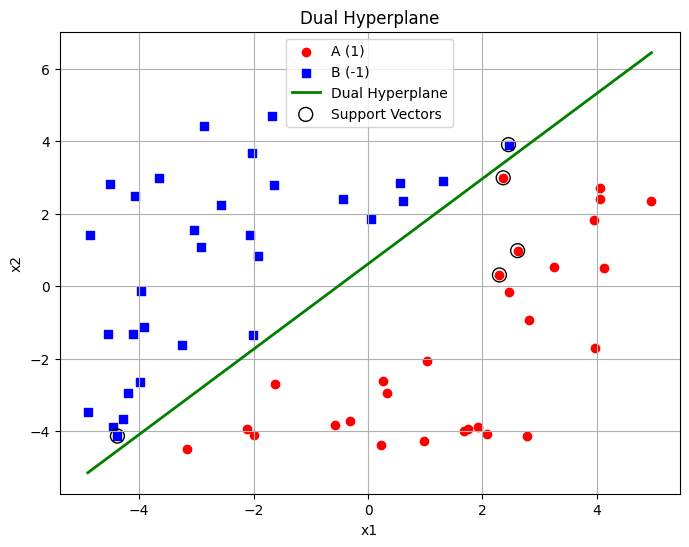

In [ ]:

xx = np.linspace(X[:,0].min(), X[:,0].max(), 400)
yy_dual = -(w_dual[0] * xx + b_dual) / w_dual[1]

plt.figure(figsize=(8,6))

plt.scatter(A[:, 0], A[:, 1], color='red', marker='o', label='A (1)')
plt.scatter(B[:, 0], B[:, 1], color='blue', marker='s', label='B (-1)')


plt.plot(xx, yy_dual, 'g-', linewidth=2, label='Dual Hyperplane')

plt.xlabel('x1')
plt.ylabel('x2')

plt.title('Dual Hyperplane')
plt.scatter(X[is_sv, 0], X[is_sv, 1], s=100, facecolors='none',
            edgecolors='k', label='Support Vectors')

plt.legend()
plt.grid(True)
plt.show()

In [ ]:

margins = y * (X @ w_dual + b_dual)
print(min(margins))

0.9999538426638193


Since the minimum of the margins is around 1, primal feasibility is true

In [ ]:
print(lambda_opt)

[-2.87812448e-06  6.08340481e-06 -1.14777607e-06 -3.74525610e-06
  5.85939155e-06  7.34138490e+00 -3.80522224e-06 -2.11632412e-06
 -4.20676789e-06  6.47688514e-06 -3.92004005e-06  3.07775232e-06
  4.96927542e-06  1.04757239e-05 -3.05376405e-07  5.91988799e-06
 -3.04147928e-06  7.97143656e-06 -5.53101304e-06  9.67025293e-06
 -1.25196053e-06  2.38841956e-07 -3.11924273e-06  1.16550273e-05
 -8.82813894e-07  5.81896815e-06 -4.32955112e-06 -9.16252954e-07
 -5.16521848e-06  4.10627859e-06 -1.49160131e-07  2.48523818e-06
  6.81465674e+00 -1.40984494e-05 -1.07839163e-06 -2.29882449e-06
  3.44519837e-06 -2.44848144e-06  3.33163837e-06  9.97687139e-07
 -6.80567018e-07 -3.52754356e-07 -2.64925772e-06 -1.08682465e-05
  3.74572854e-06 -3.58290495e-06 -3.66378920e-06  5.26814481e-01
  4.26188483e-06  3.15236238e-06 -1.62829756e-05 -1.05349925e-05
  3.40215896e-06  3.61036192e-06  3.39501843e-06 -3.29236535e-06
  3.23009599e-06 -2.28833472e-07 -1.10599501e-05]


Since all these are close to 0, dual feasibility is valid

In [ ]:
slackness = lambda_opt * (1 - margins)
max_slack_violation = np.max(np.abs(slackness))
min_slack_violation=np.min(np.abs(slackness))
print("Max Slack =",max_slack_violation)
print("Min Slack=",min_slack_violation)

Max Slack = 7.830005515705383e-05
Min Slack= 3.2602298183592184e-15


Since all max and min are both very close to 0, it verifies the complementary slackness condition


In [ ]:
w_opt-w_dual

array([ 1.12410906e-05, -4.15623200e-06])

The dual and primal are giving w that are super close-- so a hard boundary is possible in this case

CASE 2

In [ ]:
points = pd.read_csv("SVM_Case2_X.csv")
labels = pd.read_csv("SVM_Case2_Label.csv")

df = pd.concat([points, labels], axis=1)
print(df)

    3.99650990509081  0.154584548403259  -1
0           2.625855          -1.693179  -1
1           3.824863          -0.699982  -1
2          -2.150498          -0.081937   1
3           1.732260          -4.289629   1
4           1.642799           3.877392   1
5          -3.771850          -4.353664  -1
6          -0.926816          -0.638150   1
7          -2.247130           3.266295   1
8           2.166697          -1.054653  -1
9          -2.166156           1.134749   1
10          3.961989           3.186407  -1
11          3.265789           3.862350  -1
12         -1.099735           4.311116   1
13         -0.020971          -3.092154  -1
14          1.948052          -2.414177  -1
15          3.343690           3.978657  -1
16          1.096297           0.933619  -1
17          0.747372           0.038401  -1
18         -1.739578           1.128096   1
19         -0.435754           3.194222   1
20          2.137956           0.318892   1
21          3.844050          -2

In [ ]:
data = df.to_numpy()
A = data[data[:, 2] == 1][:, :2]
B = data[data[:, 2] == -1][:, :2]
X = np.vstack([A, B])
y = np.hstack([np.ones(A.shape[0]), -np.ones(B.shape[0])])

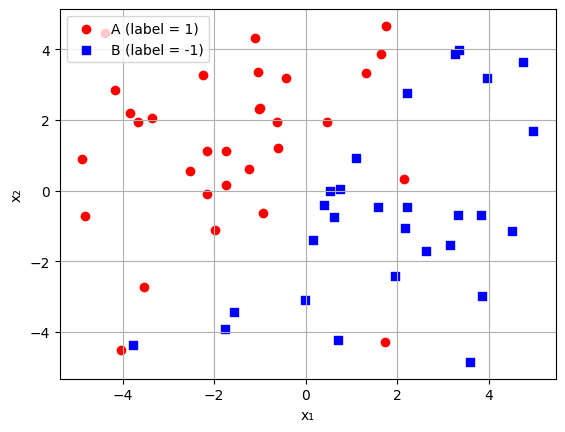

In [ ]:
plt.figure()


plt.scatter(A[:, 0], A[:, 1],color='red', marker='o', label='A (label = 1)')

plt.scatter(B[:, 0], B[:, 1], color='blue', marker='s', label='B (label = -1)')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.grid(True)
plt.show()

It is evident from the figure that a hard separation is not possible, so we will use the soft SVM

In [ ]:
C = 1.0

n_samples = X.shape[0]
Y = np.diag(y)
P = Y @ (X @ X.T) @ Y

lambd = cp.Variable(n_samples)


objective = cp.Maximize(cp.sum(lambd) - 0.5 * cp.quad_form(lambd, cp.psd_wrap(P)))


constraints = [
    lambd >= 0,
    lambd <= C,
    cp.sum(cp.multiply(lambd, y)) == 0
]

prob = cp.Problem(objective, constraints)




In [ ]:
try:
    prob.solve(solver=cp.ECOS)
except cp.error.SolverError:
    prob.solve(solver=cp.SCS, verbose=True)

(CVXPY) Jan 29 11:25:15 AM: Your problem has 59 variables, 119 constraints, and 0 parameters.
(CVXPY) Jan 29 11:25:15 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 29 11:25:15 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jan 29 11:25:15 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 29 11:25:15 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jan 29 11:25:15 AM: Compiling problem (target solver=SCS).
(CVXPY) Jan 29 11:25:15 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Jan 29 11:25:15 AM: Applying reduction FlipObjective
(CVXPY) Jan 29 11:25:15 AM: Applying reduction Dcp2Cone
(CVXPY) Jan 29 11:25:15 AM: Applying reduction CvxAttr2Constr
(CVXPY) Jan 29 11:25:15 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Jan 29 11:25:15 AM: Applying red

                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 59, constraints m: 119
cones: 	  z: primal zero / dual free vars: 1
	  l: linear vars: 118
settings: eps_ab

In [ ]:
lambda_opt=lambd.value

In [ ]:

w_soft = np.sum((lambda_opt[:, None] * y[:, None] * X), axis=0)


margin_points = (lambda_opt > 1e-5) & (lambda_opt < C - 1e-5)

if np.any(margin_points):

    idx = np.where(margin_points)[0]
    b_soft = np.mean(y[idx] - X[idx] @ w_soft)
else:

    idx = np.where(lambda_opt > 1e-5)[0]
    b_soft = np.mean(y[idx] - X[idx] @ w_soft)

In [ ]:
w_soft

array([-1.01014857,  0.6652741 ])

In [ ]:
b_soft

np.float64(-0.2705905570705387)

In [ ]:
w_opt = w_soft
b_opt = b_soft
x_min = X[:,0].min()
x_max = X[:,0].max()
xx = np.linspace(x_min, x_max, 400)

yy = -(w_opt[0] * xx + b_opt) / w_opt[1]

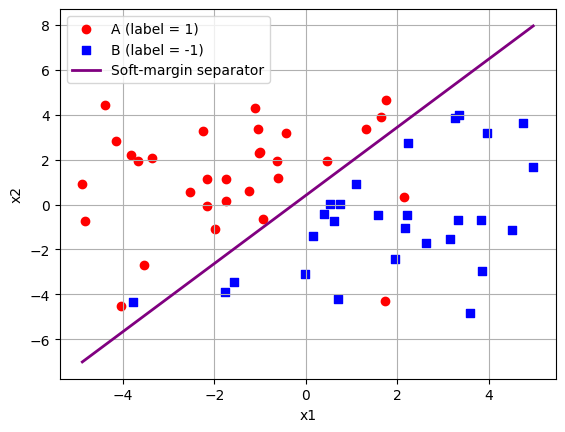

In [ ]:
plt.figure()

plt.scatter(A[:, 0], A[:, 1],color='red', marker='o', label='A (label = 1)')

plt.scatter(B[:, 0], B[:, 1], color='blue', marker='s', label='B (label = -1)')

# Separator
plt.plot(xx, yy, color='purple',linewidth=2, label='Soft-margin separator')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

decision_values = X @ w_soft + b_soft

margin_violations = np.sum(y * decision_values < 1 - 1e-5)


misclassified = np.sum(y * decision_values < -1e-5)

print(f"Total Margin Violations: {margin_violations}")
print(f"Total Misclassified Points: {misclassified}")

Total Margin Violations: 13
Total Misclassified Points: 3


In [ ]:
def gaussian_kernel(X, gamma):

    sq_dist = np.sum(X**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * (X @ X.T)
    return np.exp(-gamma * sq_dist)


gamma_val = 0.1
C = 1
n_samples = X.shape[0]

K = gaussian_kernel(X, gamma_val)


Y = np.diag(y)
P = Y @ K @ Y
lambd = cp.Variable(n_samples)

objective = cp.Maximize(cp.sum(lambd) - 0.5 * cp.quad_form(lambd, cp.psd_wrap(P)))
constraints = [lambd >= 0, lambd <= C, cp.sum(cp.multiply(lambd, y)) == 0]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

lambda_opt = lambd.value

In [ ]:

is_sv = (lambda_opt > 1e-5) & (lambda_opt < C - 1e-5)
if np.any(is_sv):
    idx = np.where(is_sv)[0][0]

    b_kernel = y[idx] - np.sum(lambda_opt * y * K[:, idx])
else:
    b_kernel = 0

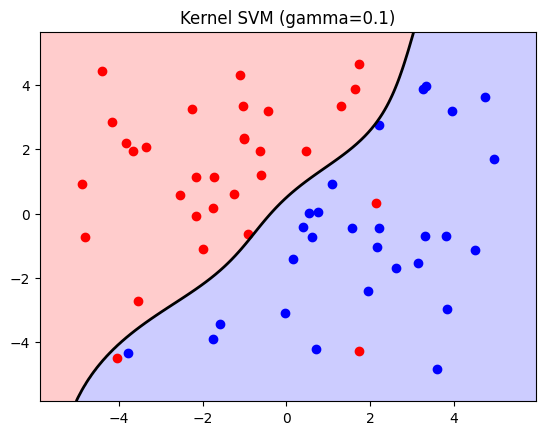

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]


def predict(points):

    sq_dist = np.sum(points**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * (points @ X.T)
    K_grid = np.exp(-gamma_val * sq_dist)
    return K_grid @ (lambda_opt * y) + b_kernel

Z = predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.2, colors=['blue', 'red'])
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
plt.scatter(A[:,0], A[:,1], color='red')
plt.scatter(B[:,0], B[:,1], color='blue')
plt.title(f"Kernel SVM (gamma={gamma_val})")
plt.show()

In [ ]:
gamma_val = 1
C = 1
n_samples = X.shape[0]

K = gaussian_kernel(X, gamma_val)


Y = np.diag(y)
P = Y @ K @ Y
lambd = cp.Variable(n_samples)

objective = cp.Maximize(cp.sum(lambd) - 0.5 * cp.quad_form(lambd, cp.psd_wrap(P)))
constraints = [lambd >= 0, lambd <= C, cp.sum(cp.multiply(lambd, y)) == 0]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

lambda_opt = lambd.value

In [ ]:

is_sv = (lambda_opt > 1e-5) & (lambda_opt < C - 1e-5)
if np.any(is_sv):
    idx = np.where(is_sv)[0][0]

    b_kernel = y[idx] - np.sum(lambda_opt * y * K[:, idx])
else:
    b_kernel = 0

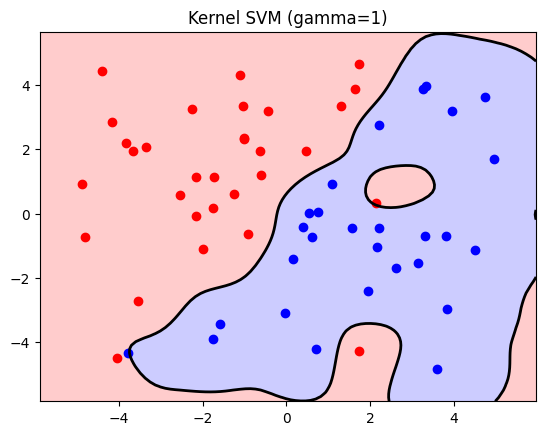

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]


def predict(points):

    sq_dist = np.sum(points**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * (points @ X.T)
    K_grid = np.exp(-gamma_val * sq_dist)
    return K_grid @ (lambda_opt * y) + b_kernel

Z = predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.2, colors=['blue', 'red'])
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
plt.scatter(A[:,0], A[:,1], color='red')
plt.scatter(B[:,0], B[:,1], color='blue')
plt.title(f"Kernel SVM (gamma={gamma_val})")
plt.show()

In [ ]:
gamma_val = 10
C = 1
n_samples = X.shape[0]

K = gaussian_kernel(X, gamma_val)


Y = np.diag(y)
P = Y @ K @ Y
lambd = cp.Variable(n_samples)

objective = cp.Maximize(cp.sum(lambd) - 0.5 * cp.quad_form(lambd, cp.psd_wrap(P)))
constraints = [lambd >= 0, lambd <= C, cp.sum(cp.multiply(lambd, y)) == 0]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

lambda_opt = lambd.value

In [ ]:

is_sv = (lambda_opt > 1e-5) & (lambda_opt < C - 1e-5)
if np.any(is_sv):
    idx = np.where(is_sv)[0][0]

    b_kernel = y[idx] - np.sum(lambda_opt * y * K[:, idx])
else:
    b_kernel = 0

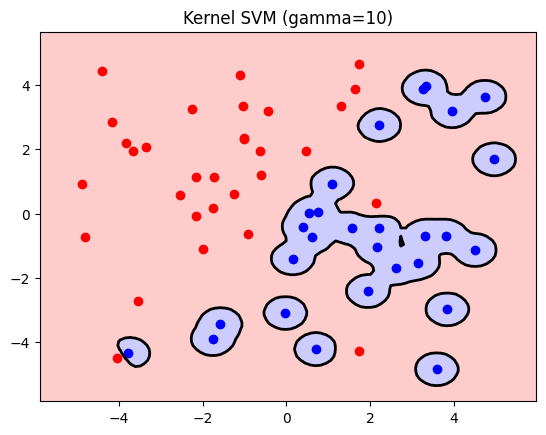

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]


def predict(points):

    sq_dist = np.sum(points**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * (points @ X.T)
    K_grid = np.exp(-gamma_val * sq_dist)
    return K_grid @ (lambda_opt * y) + b_kernel

Z = predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.2, colors=['blue', 'red'])
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
plt.scatter(A[:,0], A[:,1], color='red')
plt.scatter(B[:,0], B[:,1], color='blue')
plt.title(f"Kernel SVM (gamma={gamma_val})")
plt.show()

CASE 3

In [ ]:
points = pd.read_csv("SVM_Case3_X.csv")
labels = pd.read_csv("SVM_Case3_Label.csv")

df = pd.concat([points, labels], axis=1)
print(df)

    3.62057298433146  4.33591915842209  -1
0           1.147396          2.203432  -1
1           4.911878         -0.159615  -1
2          -2.963011          1.390311  -1
3           3.272091          3.876369  -1
4           1.758616         -3.012632  -1
5          -2.510505         -1.046337  -1
6          -0.242144          4.921753  -1
7          -1.009248         -0.976484   1
8           0.994382          1.588565   1
9           3.005228          4.013481  -1
10         -3.949312          4.953818  -1
11          3.214422          1.531633  -1
12          3.410863         -3.915636  -1
13         -1.454938         -4.638860  -1
14         -0.699305          1.180912   1
15          0.722392          0.671444   1
16          2.008247          4.619647  -1
17          2.424698          2.461055  -1
18          2.578842          1.625161  -1
19         -1.108712          0.233133   1
20         -0.706975         -2.401057  -1
21          4.563447          4.619938  -1
22         

In [ ]:
data = df.to_numpy()
A = data[data[:, 2] == 1][:, :2]
B = data[data[:, 2] == -1][:, :2]
X = np.vstack([A, B])
y = np.hstack([np.ones(A.shape[0]), -np.ones(B.shape[0])])

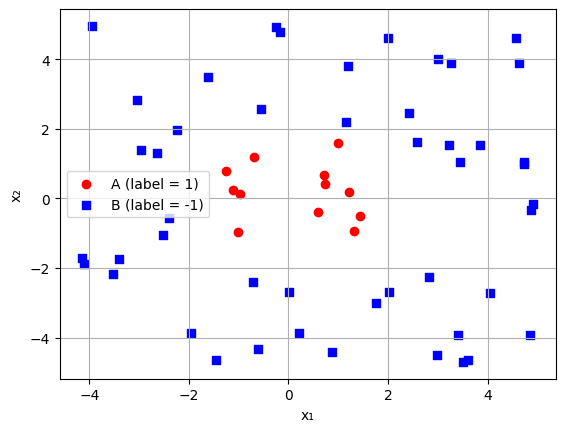

In [ ]:
plt.figure()


plt.scatter(A[:, 0], A[:, 1],color='red', marker='o', label='A (label = 1)')

plt.scatter(B[:, 0], B[:, 1], color='blue', marker='s', label='B (label = -1)')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.grid(True)
plt.show()

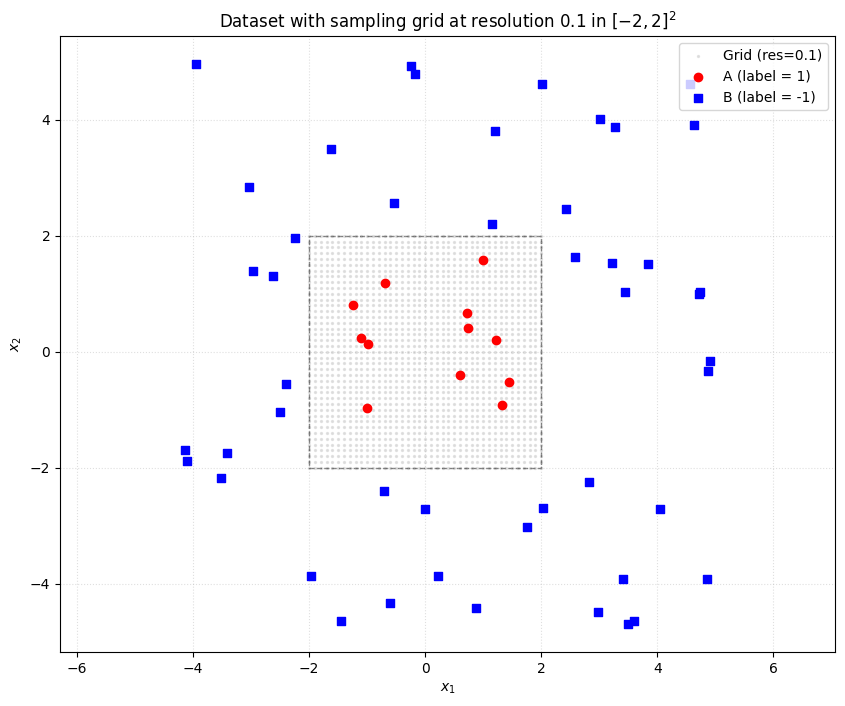

In [ ]:
resolution = 0.1
grid_range = np.arange(-2, 2 + resolution, resolution)
xx, yy = np.meshgrid(grid_range, grid_range)

plt.figure(figsize=(10, 8))


plt.scatter(xx, yy, color='lightgray', s=2, label=f'Grid (res={resolution})', alpha=0.6)


plt.scatter(A[:, 0], A[:, 1], color='red', marker='o', label='A (label = 1)', zorder=5)
plt.scatter(B[:, 0], B[:, 1], color='blue', marker='s', label='B (label = -1)', zorder=5)


plt.gca().add_patch(plt.Rectangle((-2, -2), 4, 4, fill=False, color='black', linestyle='--', alpha=0.5))


plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title(f'Dataset with sampling grid at resolution ${resolution}$ in $[-2, 2]^2$')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.4)


plt.axis('equal')
plt.show()

In [ ]:
gamma_val = 0.1
C = 1
n_samples = X.shape[0]

K = gaussian_kernel(X, gamma_val)


Y = np.diag(y)
P = Y @ K @ Y
lambd = cp.Variable(n_samples)

objective = cp.Maximize(cp.sum(lambd) - 0.5 * cp.quad_form(lambd, cp.psd_wrap(P)))
constraints = [lambd >= 0, lambd <= C, cp.sum(cp.multiply(lambd, y)) == 0]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

lambda_opt = lambd.value

In [ ]:
is_sv = (lambda_opt > 1e-5) & (lambda_opt < C - 1e-5)
if np.any(is_sv):
    idx = np.where(is_sv)[0][0]

    b_kernel = y[idx] - np.sum(lambda_opt * y * K[:, idx])
else:
    b_kernel = 0

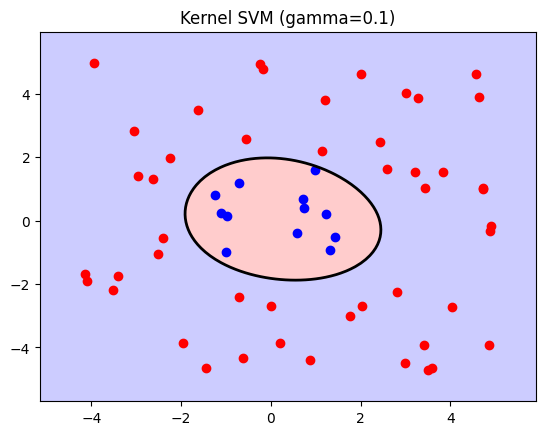

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.2, colors=['blue', 'red'])
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
plt.scatter(A[:,0], A[:,1], color='blue')
plt.scatter(B[:,0], B[:,1], color='red')
plt.title(f"Kernel SVM (gamma={gamma_val})")
plt.show()

In [ ]:
gamma_val = 1
C = 1
n_samples = X.shape[0]

K = gaussian_kernel(X, gamma_val)


Y = np.diag(y)
P = Y @ K @ Y
lambd = cp.Variable(n_samples)

objective = cp.Maximize(cp.sum(lambd) - 0.5 * cp.quad_form(lambd, cp.psd_wrap(P)))
constraints = [lambd >= 0, lambd <= C, cp.sum(cp.multiply(lambd, y)) == 0]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

lambda_opt = lambd.value

In [ ]:
is_sv = (lambda_opt > 1e-5) & (lambda_opt < C - 1e-5)
if np.any(is_sv):
    idx = np.where(is_sv)[0][0]

    b_kernel = y[idx] - np.sum(lambda_opt * y * K[:, idx])
else:
    b_kernel = 0

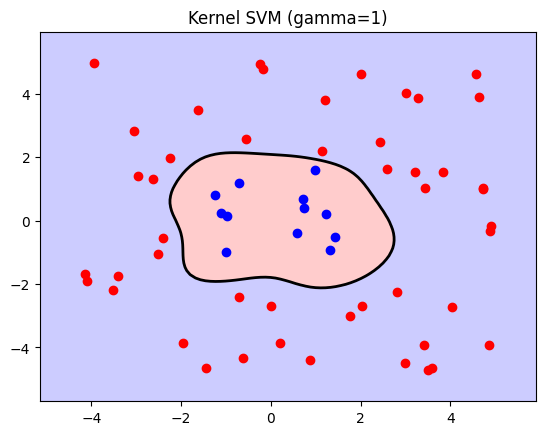

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.2, colors=['blue', 'red'])
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
plt.scatter(A[:,0], A[:,1], color='blue')
plt.scatter(B[:,0], B[:,1], color='red')
plt.title(f"Kernel SVM (gamma={gamma_val})")
plt.show()

In [ ]:
gamma_val = 10
C = 1
n_samples = X.shape[0]

K = gaussian_kernel(X, gamma_val)


Y = np.diag(y)
P = Y @ K @ Y
lambd = cp.Variable(n_samples)

objective = cp.Maximize(cp.sum(lambd) - 0.5 * cp.quad_form(lambd, cp.psd_wrap(P)))
constraints = [lambd >= 0, lambd <= C, cp.sum(cp.multiply(lambd, y)) == 0]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

lambda_opt = lambd.value

In [ ]:
is_sv = (lambda_opt > 1e-5) & (lambda_opt < C - 1e-5)
if np.any(is_sv):
    idx = np.where(is_sv)[0][0]

    b_kernel = y[idx] - np.sum(lambda_opt * y * K[:, idx])
else:
    b_kernel = 0

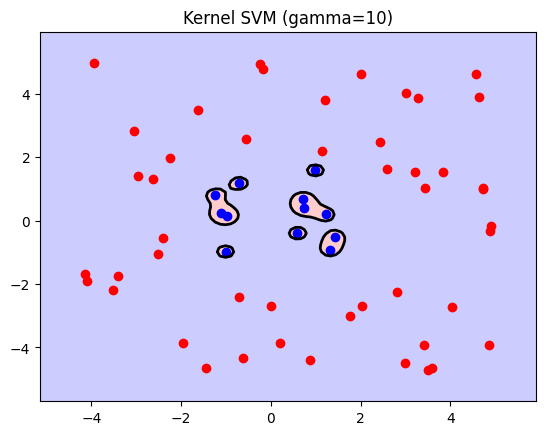

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.2, colors=['blue', 'red'])
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
plt.scatter(A[:,0], A[:,1], color='blue')
plt.scatter(B[:,0], B[:,1], color='red')
plt.title(f"Kernel SVM (gamma={gamma_val})")
plt.show()